# [Autoencoders](https://arxiv.org/abs/2201.03898)

When training CNNs, one of the problems is that we need a lot of labeled data. In the case of image classification, we need to separate images into different classes, which is a manual effort.

However, we might want to use raw (unlabeled) data for training CNN feature extractors, which is called **self-supervised learning**. Instead of labels, we will use training images as both network input and output. The main idea of **autoencoder** is that we will have an **encoder network** that converts input image into some **latent space** (normally it is just a vector of some smaller size), then the **decoder network**, whose goal would be to reconstruct the original image.

Since we are training autoencoder to capture as much of the information from the original image as possible for accurate reconstruction, the network tries to find the best **embedding** of input images to capture the meaning.

![AutoEncoder Diagram](images/autoencoder_schema.jpg)

> Image from [Keras blog](https://blog.keras.io/building-autoencoders-in-keras.html)

Let's create simplest autoencoder for MNIST!

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms
from torch import nn
from torch import optim
from tqdm import tqdm
import numpy as np
import torch.nn.functional as F
torch.manual_seed(42)
np.random.seed(42)

Define training parameters and check if the GPU is available:

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
train_size = 0.9
lr = 1e-3
eps = 1e-8
batch_size = 256
epochs = 30

print(device)

cuda:0


The following function will load the MNIST dataset and apply specified transforms to it. It will also split it into train/test datasets.

In [3]:
def mnist(train_part, transform=None):
    dataset = torchvision.datasets.MNIST('.', download=True, transform=transform)
    train_part = int(train_part * len(dataset))
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_part, len(dataset) - train_part])
    return train_dataset, test_dataset

Now let's load the dataset and define dataloaders for train and test:

In [4]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset, test_dataset = mnist(train_size, transform)

train_dataloader = torch.utils.data.DataLoader(train_dataset, drop_last=True, batch_size=batch_size, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)
dataloaders = (train_dataloader, test_dataloader)

In [5]:
def plotn(n, data, noisy=False, super_res=None):
    fig, ax = plt.subplots(1, n)
    for i, z in enumerate(data):
        if i == n:
            break
        preprocess = z[0].reshape(1, 28, 28) if z[0].shape[1] == 28 else z[0].reshape(1, 14, 14) if z[0].shape[1] == 14 else z[0]
        if super_res is not None:
            _transform = transforms.Resize((int(preprocess.shape[1] / super_res), int(preprocess.shape[2] / super_res)))
            preprocess = _transform(preprocess)

        if noisy:
            shapes = list(preprocess.shape)
            preprocess += noisify(shapes)

        ax[i].imshow(preprocess[0])
    plt.show()

In [6]:
def noisify(shapes):
    return np.random.normal(loc=0.5, scale=0.3, size=shapes)

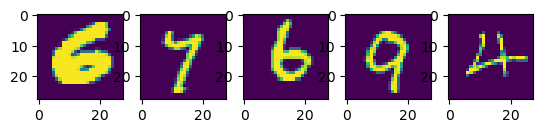

In [7]:
plotn(5, train_dataset)

In [7]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(3, 3), padding='same')
        self.maxpool1 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv2 = nn.Conv2d(16, 8, kernel_size=(3, 3), padding='same')
        self.maxpool2 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv3 = nn.Conv2d(8, 8, kernel_size=(3, 3), padding='same')
        self.maxpool3 = nn.MaxPool2d(kernel_size=(2, 2), padding=(1, 1))
        self.relu = nn.ReLU()

    def forward(self, input):
        hidden1 = self.maxpool1(self.relu(self.conv1(input)))
        hidden2 = self.maxpool2(self.relu(self.conv2(hidden1)))
        encoded = self.maxpool3(self.relu(self.conv3(hidden2)))
        return encoded

In [8]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(8, 8, kernel_size=(3, 3), padding='same')
        self.upsample1 = nn.Upsample(scale_factor=(2, 2))
        self.conv2 = nn.Conv2d(8, 8, kernel_size=(3, 3), padding='same')
        self.upsample2 = nn.Upsample(scale_factor=(2, 2))
        self.conv3 = nn.Conv2d(8, 16, kernel_size=(3, 3))
        self.upsample3 = nn.Upsample(scale_factor=(2, 2))
        self.conv4 = nn.Conv2d(16, 1, kernel_size=(3, 3), padding='same')
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, input):
        hidden1 = self.upsample1(self.relu(self.conv1(input)))
        hidden2 = self.upsample2(self.relu(self.conv2(hidden1)))
        hidden3 = self.upsample3(self.relu(self.conv3(hidden2)))
        decoded = self.sigmoid(self.conv4(hidden3))
        return decoded

In [9]:
class AutoEncoder(nn.Module):
    def __init__(self, super_resolution=False):
        super().__init__()
        if not super_resolution:
            self.encoder = Encoder()
        else:
            self.encoder = SuperResolutionEncoder()
        self.decoder = Decoder()

    def forward(self, input):
        encoded = self.encoder(input)
        decoded = self.decoder(encoded)
        return decoded

In [10]:
model = AutoEncoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, eps=eps)
loss_fn = nn.BCELoss()

In [12]:
model

AutoEncoder(
  (encoder): Encoder(
    (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (maxpool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (maxpool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (maxpool3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(1, 1), dilation=1, ceil_mode=False)
    (relu): ReLU()
  )
  (decoder): Decoder(
    (conv1): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (upsample1): Upsample(scale_factor=(2.0, 2.0), mode='nearest')
    (conv2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (upsample2): Upsample(scale_factor=(2.0, 2.0), mode='nearest')
    (conv3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (upsample3): Upsample(scale_factor=

In [10]:
def train(dataloaders, model, loss_fn, optimizer, epochs, device, noisy=None, super_res=None):
    tqdm_iter = tqdm(range(epochs))
    train_dataloader, test_dataloader = dataloaders[0], dataloaders[1]

    for epoch in tqdm_iter:
        model.train()
        train_loss = 0.0
        test_loss = 0.0

        for batch in train_dataloader:
            imgs, labels = batch
            shapes = list(imgs.shape)

            if super_res is not None:
                shapes[2], shapes[3] = int(shapes[2] / super_res), int(shapes[3] / super_res)
                _transform = transforms.Resize((shapes[2], shapes[3]))
                imgs_transformed = _transform(imgs)
                imgs_transformed = imgs_transformed.to(device)

            imgs = imgs.to(device)
            labels = labels.to(device)

            if noisy is not None:
                noisy_tensor = noisy[0]
            else:
                noisy_tensor = torch.zeros(tuple(shapes)).to(device)

            if super_res is None:
                imgs_noisy = imgs + noisy_tensor
            else:
                imgs_noisy = imgs_transformed + noisy_tensor

            imgs_noisy = torch.clamp(imgs_noisy, 0., 1.)

            preds = model(imgs_noisy)
            loss = loss_fn(preds, imgs)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            for batch in test_dataloader:
                imgs, labels = batch
                shapes = list(imgs.shape)

                if super_res is not None:
                    shapes[2], shapes[3] = int(shapes[2] / super_res), int(shapes[3] / super_res)
                    _transform = transforms.Resize((shapes[2], shapes[3]))
                    imgs_transformed = _transform(imgs)
                    imgs_transformed = imgs_transformed.to(device)


                imgs = imgs.to(device)
                labels = labels.to(device)

                if noisy is not None:
                    test_noisy_tensor = noisy[1]
                else:
                    test_noisy_tensor = torch.zeros(tuple(shapes)).to(device)

                if super_res is None:
                    imgs_noisy = imgs + test_noisy_tensor
                else:
                    imgs_noisy = imgs_transformed + test_noisy_tensor

                imgs_noisy = torch.clamp(imgs_noisy, 0., 1.)

                preds = model(imgs_noisy)
                loss = loss_fn(preds, imgs)

                test_loss += loss.item()

        train_loss /= len(train_dataloader)
        test_loss /= len(test_dataloader)

        tqdm_dct = {'train loss:': train_loss, 'test loss:': test_loss}
        tqdm_iter.set_postfix(tqdm_dct, refresh=True)
        tqdm_iter.refresh()

In [12]:
train(dataloaders, model, loss_fn, optimizer, epochs, device)

100%|██████████| 30/30 [07:47<00:00, 15.57s/it, train loss:=0.103, test loss:=0.103]


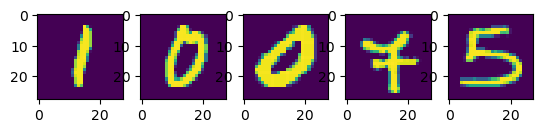

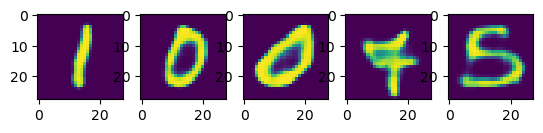

In [13]:
model.eval()
predictions = []
plots = 5
for i, data in enumerate(test_dataset):
    if i == plots:
        break
    predictions.append(model(data[0].to(device).unsqueeze(0)).detach().cpu())
plotn(plots, test_dataset)
plotn(plots, predictions)

> **Task 1**: Try to train autoencoder with very small latent vector size, eg. 2, and plot the dots corresponding to different digits. *Hint: Use fully-connected dense layer after the convoluitonal part to reduce the vector size to the required value.*

> **Task 2**: Starting from different digits, obtain their latent space representations, and see what effect adding some noise to the latent space has on the resulting digits.

In [35]:
# TASK 1
class EncoderSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(3, 3), padding='same')
        self.maxpool1 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv2 = nn.Conv2d(16, 8, kernel_size=(3, 3), padding='same')
        self.maxpool2 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv3 = nn.Conv2d(8, 8, kernel_size=(3, 3), padding='same')
        self.maxpool3 = nn.MaxPool2d(kernel_size=(2, 2))
        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(8*3*3, 2)

    def forward(self, input):
        hidden1 = self.maxpool1(self.relu(self.conv1(input)))
        hidden2 = self.maxpool2(self.relu(self.conv2(hidden1)))
        hidden3 = self.maxpool3(self.relu(self.conv3(hidden2)))
        encoded = self.flatten(hidden3)
        z = self.fc_mu(encoded)
        return z, encoded

In [47]:
import torch.nn.functional as F

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(2, 8*3*3)

        self.conv1 = nn.Conv2d(8, 8, kernel_size=(3, 3), padding='same')
        self.upsample1 = nn.Upsample(scale_factor=(2, 2))
        self.conv2 = nn.Conv2d(8, 8, kernel_size=(3, 3), padding='same')
        self.upsample2 = nn.Upsample(scale_factor=(2, 2))
        self.conv3 = nn.Conv2d(8, 16, kernel_size=(3, 3), padding='same')
        self.upsample3 = nn.Upsample(scale_factor=(2, 2))
        self.conv4 = nn.Conv2d(16, 1, kernel_size=(3, 3), padding='same')
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, input):
        hidden0 = self.fc(input).view(-1, 8, 3, 3)
        hidden1 = self.upsample1(self.relu(self.conv1(hidden0)))
        hidden2 = self.upsample2(self.relu(self.conv2(hidden1)))
        hidden3 = self.upsample3(self.relu(self.conv3(hidden2)))
        hidden4 = self.conv4(hidden3)
        decoded = F.interpolate(hidden4, size=(28, 28), mode='bilinear')
        return self.sigmoid(decoded)

In [48]:
class AutoEncoderSmall(nn.Module):
    def __init__(self, super_resolution=False):
        super().__init__()
        if not super_resolution:
            self.encoder = EncoderSmall()
        else:
            self.encoder = SuperResolutionEncoder()
        self.decoder = Decoder()

    def forward(self, input):
        z, encoded = self.encoder(input)
        decoded = self.decoder(z)
        return decoded, z

In [49]:
modelSmall = AutoEncoderSmall().to(device)
opt = optim.Adam(modelSmall.parameters(), lr=lr)
loss_fn = nn.BCELoss()

In [54]:
def get_embeddings(loader):
    model.eval()
    zs, ys = [], []
    for x,y in loader:
        x = x.to(device, non_blocking=True)
        with torch.no_grad():  # <- ensures no gradients are tracked
            z, _ = modelSmall.encoder(x)
        zs.append(z.detach().cpu())
        ys.append(y)
    return torch.cat(zs, 0).numpy(), torch.cat(ys, 0).numpy()

In [62]:
def trainSmall(dataloaders, model, loss_fn, optimizer, epochs, device, noisy=None, super_res=None):
    tqdm_iter = tqdm(range(epochs))
    train_dataloader, test_dataloader = dataloaders[0], dataloaders[1]

    for epoch in tqdm_iter:
        model.train()
        train_loss = 0.0
        test_loss = 0.0

        for batch in train_dataloader:
            imgs, labels = batch
            shapes = list(imgs.shape)

            if super_res is not None:
                shapes[2], shapes[3] = int(shapes[2] / super_res), int(shapes[3] / super_res)
                _transform = transforms.Resize((shapes[2], shapes[3]))
                imgs_transformed = _transform(imgs)
                imgs_transformed = imgs_transformed.to(device)

            imgs = imgs.to(device)
            labels = labels.to(device)

            if noisy is not None:
                noisy_tensor = noisy[0]
            else:
                noisy_tensor = torch.zeros(tuple(shapes)).to(device)

            if super_res is None:
                imgs_noisy = imgs + noisy_tensor
            else:
                imgs_noisy = imgs_transformed + noisy_tensor

            imgs_noisy = torch.clamp(imgs_noisy, 0., 1.)

            recons, preds = model(imgs_noisy)
            loss = loss_fn(recons, imgs)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            for batch in test_dataloader:
                imgs, labels = batch
                shapes = list(imgs.shape)

                if super_res is not None:
                    shapes[2], shapes[3] = int(shapes[2] / super_res), int(shapes[3] / super_res)
                    _transform = transforms.Resize((shapes[2], shapes[3]))
                    imgs_transformed = _transform(imgs)
                    imgs_transformed = imgs_transformed.to(device)


                imgs = imgs.to(device)
                labels = labels.to(device)

                if noisy is not None:
                    test_noisy_tensor = noisy[1]
                else:
                    test_noisy_tensor = torch.zeros(tuple(shapes)).to(device)

                if super_res is None:
                    imgs_noisy = imgs + test_noisy_tensor
                else:
                    imgs_noisy = imgs_transformed + test_noisy_tensor

                imgs_noisy = torch.clamp(imgs_noisy, 0., 1.)

                recons, preds = model(imgs_noisy)
                loss = loss_fn(recons, imgs)

                test_loss += loss.item()

        train_loss /= len(train_dataloader)
        test_loss /= len(test_dataloader)

        tqdm_dct = {'train loss:': train_loss, 'test loss:': test_loss}
        tqdm_iter.set_postfix(tqdm_dct, refresh=True)
        tqdm_iter.refresh()

In [ ]:
trainSmall(dataloaders, modelSmall, loss_fn, opt, epochs, device)

100%|██████████| 30/30 [08:58<00:00, 17.95s/it, train loss:=0.201, test loss:=0.201]


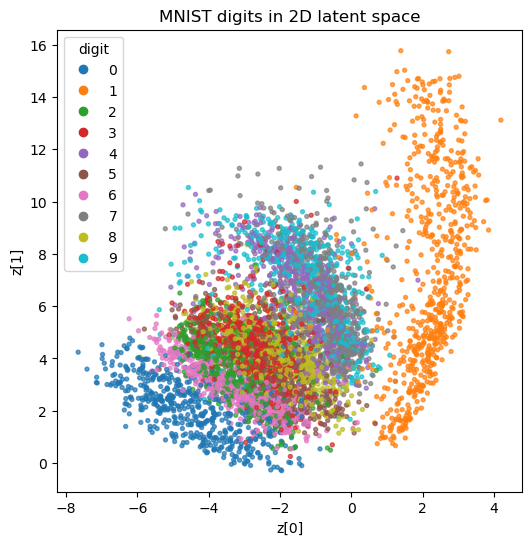

In [56]:
Z, Y = get_embeddings(test_dataloader)

# --- plot: 2D latent colored by digit ---
plt.figure(figsize=(6,6))
scatter = plt.scatter(Z[:,0], Z[:,1], c=Y, s=8, alpha=0.7, cmap="tab10")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("MNIST digits in 2D latent space")

# Create legend with matching colors
handles = [plt.Line2D([], [], marker='o', color=scatter.cmap(scatter.norm(i)),
                      linestyle='', markersize=6) for i in range(10)]
plt.legend(handles, list(range(10)), title="digit", loc="best")

plt.show()

In [108]:
# TASK 2
class EncoderLarge(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16,8,3,padding=1)
        self.pool2 = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(8,8,3,padding=1)
        self.pool3 = nn.MaxPool2d(2, ceil_mode=True)
        self.relu = nn.ReLU()

    def forward(self, x):
        h = self.pool1(self.relu(self.conv1(x)))
        h = self.pool2(self.relu(self.conv2(h)))
        z = self.pool3(self.relu(self.conv3(h)))  # 8 channels latent
        return z

class DecoderLarge(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(8, 8, 3, padding='same')
        self.conv2 = nn.Conv2d(8, 8, 3, padding='same')
        self.conv3 = nn.Conv2d(8, 16, 3, padding='same')
        self.conv4 = nn.Conv2d(16, 1, 3, padding='same')
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        self.upsample1 = nn.Upsample(scale_factor=2)  # 3->6
        self.upsample2 = nn.Upsample(scale_factor=2)  # 6->12
        self.upsample3 = nn.Upsample(scale_factor=2)  # 12->24

    def forward(self, z):
        h = self.upsample1(self.relu(self.conv1(z))) 
        h = self.upsample2(self.relu(self.conv2(h))) 
        h = self.upsample3(self.relu(self.conv3(h))) 
        h = nn.functional.interpolate(h, size=(28,28))  # resize to MNIST size
        return self.sigmoid(self.conv4(h))
    
class AutoEncoderLarge(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = EncoderLarge()
        self.decoder = DecoderLarge()

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

In [109]:
def trainLarge(dataloaders, model, loss_fn, optimizer, epochs, device, noisy=None):
    train_loader, test_loader = dataloaders
    tqdm_iter = tqdm(range(epochs))

    for epoch in tqdm_iter:
        model.train()
        train_loss = 0.0
        test_loss = 0.0

        # --- Training ---
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            
            # Optionally add noise directly to input images
            if noisy is not None:
                imgs_noisy = imgs + noisy(imgs.shape)
            else:
                imgs_noisy = imgs

            imgs_noisy = torch.clamp(imgs_noisy, 0., 1.)

            # Forward pass
            recon, _ = model(imgs_noisy)
            loss = loss_fn(recon, imgs)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # --- Evaluation ---
        model.eval()
        with torch.no_grad():
            for imgs, _ in test_loader:
                imgs = imgs.to(device)
                recon, _ = model(imgs)
                loss = loss_fn(recon, imgs)
                test_loss += loss.item()

        train_loss /= len(train_loader)
        test_loss /= len(test_loader)
        tqdm_iter.set_postfix({'train_loss': train_loss, 'test_loss': test_loss})
        tqdm_iter.refresh()

In [110]:
latent_dim = 16
modelLarge = AutoEncoderLarge().to(device)
optimizerLarge = optim.Adam(modelLarge.parameters(), lr=lr, eps=eps)
loss_fnLarge = nn.BCELoss()

In [111]:
trainLarge(dataloaders, modelLarge, loss_fnLarge, optimizerLarge, epochs, device)


100%|██████████| 30/30 [07:31<00:00, 15.04s/it, train_loss=0.0949, test_loss=0.095] 


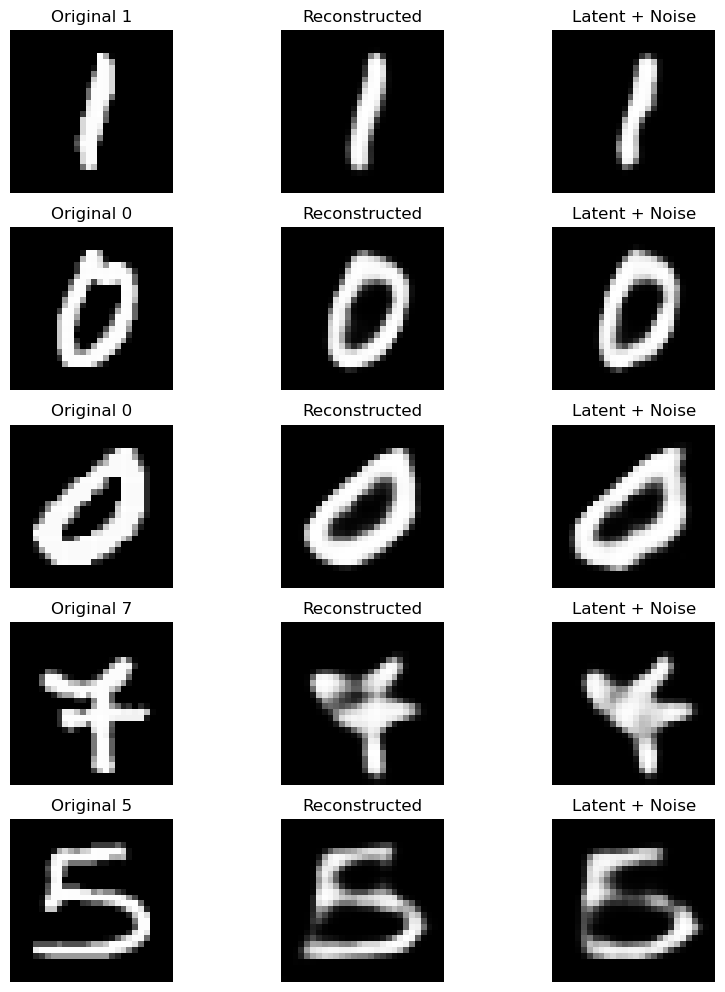

In [116]:
def get_latents(model, loader, device):
    model.eval()
    latents, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            z = model.encoder(x)          # get latent code
            latents.append(z.cpu())
            labels.append(y)
    return torch.cat(latents, 0), torch.cat(labels, 0)

# --- 2. Function to add noise to latent codes ---
def add_noise(z, sigma=0.1):
    noise = torch.randn_like(z) * sigma
    return z + noise

# --- 3. Function to reconstruct images from latent codes ---
def reconstruct_from_latent(model, z):
    model.eval()
    with torch.no_grad():
        recon = model.decoder(z.to(device))
    return recon.cpu()

# --- 4. Choose some digits from test set ---
num_samples = 5
sample_images = [test_dataset[i][0].unsqueeze(0) for i in range(num_samples)]
sample_labels = [test_dataset[i][1] for i in range(num_samples)]
sample_batch = torch.cat(sample_images, dim=0).to(device)

# --- 5. Encode them into latent space ---
z_orig = modelLarge.encoder(sample_batch)

# --- 6. Add noise to latent codes ---
z_noisy = add_noise(z_orig, sigma=0.5)

# --- 7. Decode original and noisy latent codes ---
recon_orig = reconstruct_from_latent(modelLarge, z_orig)
recon_noisy = reconstruct_from_latent(modelLarge, z_noisy)

# --- 8. Plot original, reconstructions, and noisy reconstructions ---
def plot_latent_effect(orig, recon_orig, recon_noisy, labels):
    n = orig.shape[0]
    fig, axes = plt.subplots(n, 3, figsize=(9, n*2))
    for i in range(n):
        axes[i,0].imshow(orig[i,0].cpu(), cmap='gray')
        axes[i,0].set_title(f'Original {labels[i]}')
        axes[i,0].axis('off')

        axes[i,1].imshow(recon_orig[i,0].cpu(), cmap='gray')
        axes[i,1].set_title('Reconstructed')
        axes[i,1].axis('off')

        axes[i,2].imshow(recon_noisy[i,0].cpu(), cmap='gray')
        axes[i,2].set_title('Latent + Noise')
        axes[i,2].axis('off')
    plt.tight_layout(pad=1.0)
    plt.show()

plot_latent_effect(sample_batch, recon_orig, recon_noisy, sample_labels)

## Denoising

Autoencoders can be effectively used to remove noise from images. In order to train denoiser, we will start with noise-free images, and add artificial noise to them. Then, we will feed autoencoder with noisy images as input, and noise-free images as output.

Let's see how this works for MNIST:

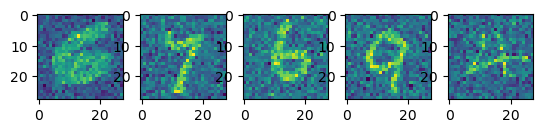

In [14]:
plotn(5, train_dataset, noisy=True)

In [15]:
model = AutoEncoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, eps=eps)
loss_fn = nn.BCELoss()

In [16]:
print(lr, eps)

0.001 1e-08


In [ ]:
noisy_tensor = torch.FloatTensor(noisify([256, 1, 28, 28])).to(device)
test_noisy_tensor = torch.FloatTensor(noisify([1, 1, 28, 28])).to(device)
noisy_tensors = (noisy_tensor, test_noisy_tensor)

In [18]:
train(dataloaders, model, loss_fn, optimizer, 100, device, noisy=noisy_tensors)

100%|██████████| 100/100 [24:50<00:00, 14.90s/it, train loss:=0.116, test loss:=0.116]


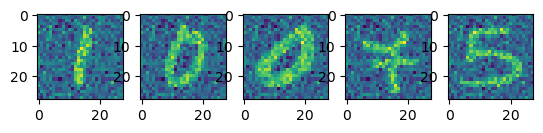

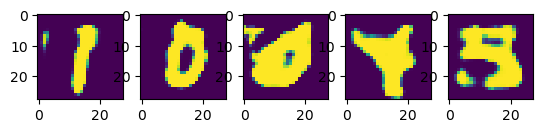

In [19]:
model.eval()
predictions = []
noise = []
plots = 5
for i, data in enumerate(test_dataset):
    if i == plots:
        break
    shapes = data[0].shape
    noisy_data = data[0] + test_noisy_tensor[0].detach().cpu()
    noise.append(noisy_data)
    predictions.append(model(noisy_data.to(device).unsqueeze(0)).detach().cpu())
plotn(plots, noise)
plotn(plots, predictions)

> **Exercise:** See how denoiser trained on MNIST digits works for different images. As an example, you can take [Fashion MNIST](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST) dataset, which has the same image size. Note that denoiser works well only on the same image type that it was trained on (i.e. for the same probability distribution of input data).

In [20]:
def fashionmnist(train_part, transform=None):
    dataset = torchvision.datasets.FashionMNIST('.', download=True, transform=transform)
    train_part = int(train_part * len(dataset))
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_part, len(dataset) - train_part])
    return train_dataset, test_dataset

In [21]:
transform = transforms.Compose([transforms.ToTensor()])

fashiontrain_dataset, fashiontest_dataset = fashionmnist(train_size, transform)

fashiontrain_dataloader = torch.utils.data.DataLoader(
    fashiontrain_dataset, 
    drop_last=True, 
    batch_size=batch_size, 
    shuffle=True
)
fashiontest_dataloader = torch.utils.data.DataLoader(fashiontest_dataset, batch_size=1, shuffle=False)
fashiondataloaders = (fashiontrain_dataloader, fashiontest_dataloader)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.17MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 250kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.44MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


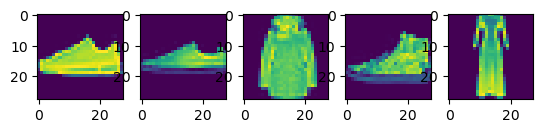

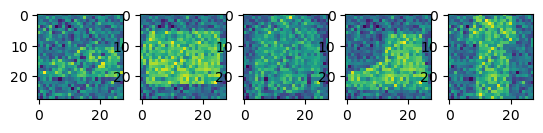

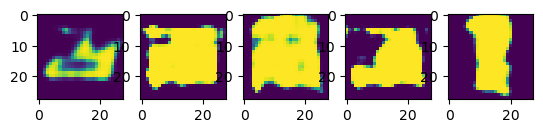

In [23]:
predictions = []
noise = []
plots = 5
for i, data in enumerate(fashiontest_dataset):
    if i == plots:
        break
    shapes = data[0].shape
    noisy_data = data[0] + test_noisy_tensor[0].detach().cpu()
    noise.append(noisy_data)
    predictions.append(model(noisy_data.to(device).unsqueeze(0)).detach().cpu())
plotn(5, fashiontrain_dataset)
plotn(plots, noise)
plotn(plots, predictions)

## Super-Resolution

Similarly to denoiser, we can train autoencoders to increase the resolution of the image. To train super-resolution network, we will start with high-resolution images, and automatically downscale them to produce network inputs. We will then feed autoencoder with small images as inputs and high-resolution images as outputs.

For that let's downscale image to 14x14 at train.

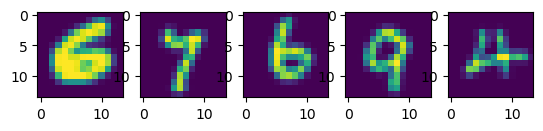

In [24]:
super_res_koeff = 2.0
plotn(5, train_dataset, super_res=super_res_koeff)

In [11]:
class SuperResolutionEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(3, 3), padding='same')
        self.maxpool1 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv2 = nn.Conv2d(16, 8, kernel_size=(3, 3), padding='same')
        self.maxpool2 = nn.MaxPool2d(kernel_size=(2, 2), padding=(1, 1))
        self.relu = nn.ReLU()

    def forward(self, input):
        hidden1 = self.maxpool1(self.relu(self.conv1(input)))
        encoded = self.maxpool2(self.relu(self.conv2(hidden1)))
        return encoded

In [26]:
model = AutoEncoder(super_resolution=True).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, eps=eps)
loss_fn = nn.BCELoss()

In [27]:
train(dataloaders, model, loss_fn, optimizer, epochs, device, super_res=2.0)

100%|██████████| 30/30 [08:11<00:00, 16.39s/it, train loss:=0.101, test loss:=0.101]


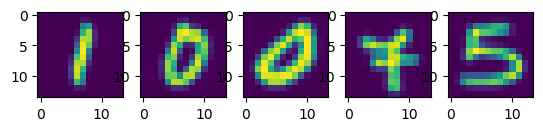

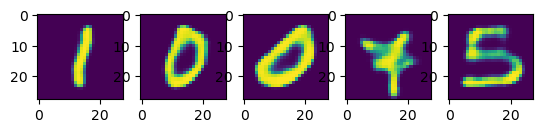

In [28]:
model.eval()
predictions = []
plots = 5
shapes = test_dataset[0][0].shape

for i, data in enumerate(test_dataset):
    if i == plots:
        break
    _transform = transforms.Resize((int(shapes[1] / super_res_koeff), int(shapes[2] / super_res_koeff)))
    predictions.append(model(_transform(data[0]).to(device).unsqueeze(0)).detach().cpu())
plotn(plots, test_dataset, super_res=super_res_koeff)
plotn(plots, predictions)

> **Exercise**: Try to train super-resolution network on [CIFAR-10](https://pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html) for 2x and 4x upscaling. Use noise as input to 4x upscaling model and observe the result.

In [30]:
def cifar10(train_part, transform=None):
    dataset = torchvision.datasets.CIFAR10('.', download=True, transform=transform)
    train_part = int(train_part * len(dataset))
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_part, len(dataset) - train_part])
    return train_dataset, test_dataset

In [88]:
cifartransform = transforms.Compose([transforms.ToTensor()])

cifartrain_dataset, cifartest_dataset = cifar10(train_size, cifartransform)

cifartrain_dataloader = torch.utils.data.DataLoader(
    cifartrain_dataset, 
    drop_last=True, 
    batch_size=batch_size, 
    shuffle=True
)
cifartest_dataloader = torch.utils.data.DataLoader(cifartest_dataset, batch_size=1, shuffle=False)
cifardataloaders = (cifartrain_dataloader, cifartest_dataloader)

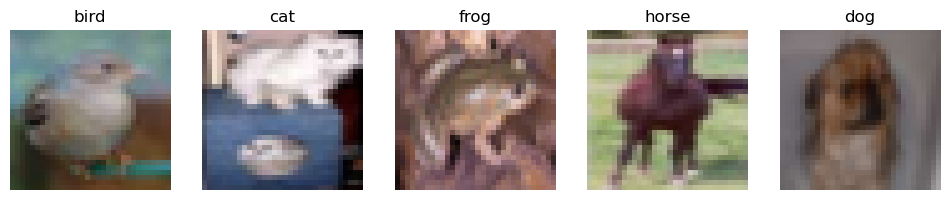

In [73]:
classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    img, label = cifartrain_dataset[i]
    img = img.permute(1, 2, 0)  # (C, H, W) → (H, W, C) for plotting
    axes[i].imshow(img)
    axes[i].set_title(classes[label])
    axes[i].axis('off')

plt.show()

In [41]:
class cifarSuperResolutionEncoder(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=3, padding='same')
        self.maxpool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding='same')
        self.maxpool2 = nn.MaxPool2d(2, 2, padding=0)
        self.relu = nn.ReLU()

    def forward(self, x):
        hidden1 = self.maxpool1(self.relu(self.conv1(x)))
        encoded = self.maxpool2(self.relu(self.conv2(hidden1)))
        return encoded

In [42]:
class cifarDecoder(nn.Module):
    def __init__(self, out_channels=3):
        super().__init__()
        self.conv1 = nn.Conv2d(8, 8, 3, padding='same')
        self.upsample1 = nn.Upsample(scale_factor=2)
        self.conv2 = nn.Conv2d(8, 8, 3, padding='same')
        self.upsample2 = nn.Upsample(scale_factor=2)
        self.conv3 = nn.Conv2d(8, 16, 3)
        self.upsample3 = nn.Upsample(scale_factor=2)
        self.conv4 = nn.Conv2d(16, out_channels, 3, padding='same')
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        hidden1 = self.upsample1(self.relu(self.conv1(x)))
        hidden2 = self.upsample2(self.relu(self.conv2(hidden1)))
        hidden3 = self.upsample3(self.relu(self.conv3(hidden2)))
        decoded = self.sigmoid(self.conv4(hidden3))
        return decoded

In [43]:
class cifarAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = cifarSuperResolutionEncoder()
        self.decoder = cifarDecoder()

    def forward(self, input):
        encoded = self.encoder(input)
        decoded = self.decoder(encoded)
        return decoded

In [44]:
loss_fn = nn.MSELoss()

model2 = cifarAutoEncoder().to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=lr)

model4 = cifarAutoEncoder().to(device)
optimizer4 = optim.Adam(model4.parameters(), lr=lr)

model4Noisy = cifarAutoEncoder().to(device)
optimizer4Noisy = optim.Adam(model4Noisy.parameters(), lr=lr)

In [46]:
def cifartrain(dataloaders, model, loss_fn, optimizer, epochs, device, noisy=None, super_res=None):
    train_loader, test_loader = dataloaders
    tqdm_iter = tqdm(range(epochs))

    for epoch in tqdm_iter:
        model.train()
        train_loss = 0.0

        for imgs, _ in train_loader:
            shapes = list(imgs.shape)

            # Downsample input if super_res is set
            if super_res is not None:
                h, w = int(shapes[2] / super_res), int(shapes[3] / super_res)
                _transform = transforms.Resize((h, w))
                imgs_transformed = _transform(imgs).to(device)
            else:
                imgs_transformed = imgs.to(device)

            # Add noise if provided
            if noisy is not None:
                noisy_tensor = noisy[0]
            else:
                noisy_tensor = torch.zeros_like(imgs_transformed).to(device)

            imgs_noisy = torch.clamp(imgs_transformed + noisy_tensor, 0., 1.)

            # Forward pass
            preds = model(imgs_noisy)

            # Ensure output matches target size
            if preds.shape[2:] != imgs.shape[2:]:
                preds = F.interpolate(preds, size=imgs.shape[2:], mode='bilinear', align_corners=False)

            imgs = imgs.to(device)
            loss = loss_fn(preds, imgs)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # ----- Evaluation -----
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for imgs, _ in test_loader:
                shapes = list(imgs.shape)

                # Downsample input if super_res is set
                if super_res is not None:
                    h, w = int(shapes[2] / super_res), int(shapes[3] / super_res)
                    _transform = transforms.Resize((h, w))
                    imgs_transformed = _transform(imgs).to(device)
                else:
                    imgs_transformed = imgs.to(device)

                # Add noise if provided
                if noisy is not None:
                    test_noisy_tensor = noisy[1]
                else:
                    test_noisy_tensor = torch.zeros_like(imgs_transformed).to(device)

                imgs_noisy = torch.clamp(imgs_transformed + test_noisy_tensor, 0., 1.)

                preds = model(imgs_noisy)

                # Ensure output matches target size
                if preds.shape[2:] != imgs.shape[2:]:
                    preds = F.interpolate(preds, size=imgs.shape[2:], mode='bilinear', align_corners=False)

                imgs = imgs.to(device)
                loss = loss_fn(preds, imgs)
                test_loss += loss.item()

        train_loss /= len(train_loader)
        test_loss /= len(test_loader)

        tqdm_iter.set_postfix({'train_loss': train_loss, 'test_loss': test_loss})
        tqdm_iter.refresh()

In [78]:
def plot_sr_comparison(model, test_dataset, device, super_res=2, plots=5, noisy=None):
    model.eval()
    fig, axes = plt.subplots(plots, 3, figsize=(12, plots*4))
    
    for i, data in enumerate(test_dataset):
        if i == plots:
            break
        
        # Original high-res image
        img = data[0].to(device)  # C×H×W
        img_batch = img.unsqueeze(0)

        # Create low-res input by downscaling
        h_lr, w_lr = int(img.shape[1] / super_res), int(img.shape[2] / super_res)
        img_lr = F.interpolate(img_batch, size=(h_lr, w_lr), mode='bilinear', align_corners=False)

        # Add noise if provided
        if noisy is not None:
            img_lr = torch.clamp(img_lr + noisy, 0., 1.)

        # Model super-res output
        with torch.no_grad():
            pred = model(img_lr)
            # Ensure output matches original high-res size
            pred = F.interpolate(pred, size=(img.shape[1], img.shape[2]), mode='bilinear', align_corners=False)
            pred = torch.clamp(pred, 0., 1.)

        # Upsample low-res input for visualization
        img_lr_vis = F.interpolate(img_lr, size=(img.shape[1], img.shape[2]), mode='nearest')

        # Convert tensors to numpy H×W×C
        def to_np(x):
            x = x.cpu()
            if x.shape[0] == 1:  # grayscale
                return x.squeeze(0).numpy()
            else:  # RGB
                return x.permute(1, 2, 0).numpy()

        imgs_to_plot = [img_lr_vis.squeeze(0), img.squeeze(0), pred.squeeze(0)]

        for j, ax in enumerate(axes[i]):
            ax.imshow(to_np(imgs_to_plot[j]))
            ax.set_title(['Low-Res Input', 'Original', 'Super-Res'][j])
            ax.set_xlabel('Width')
            ax.set_ylabel('Height')
            ax.set_xticks(range(0, imgs_to_plot[j].shape[2]+1, 4))
            ax.set_yticks(range(0, imgs_to_plot[j].shape[1]+1, 4))
    
    plt.tight_layout()
    plt.show()


In [63]:
cifartrain(cifardataloaders, model2, loss_fn, optimizer2, epochs, device, super_res=2)

100%|██████████| 30/30 [07:20<00:00, 14.69s/it, train_loss=0.0122, test_loss=0.0122]


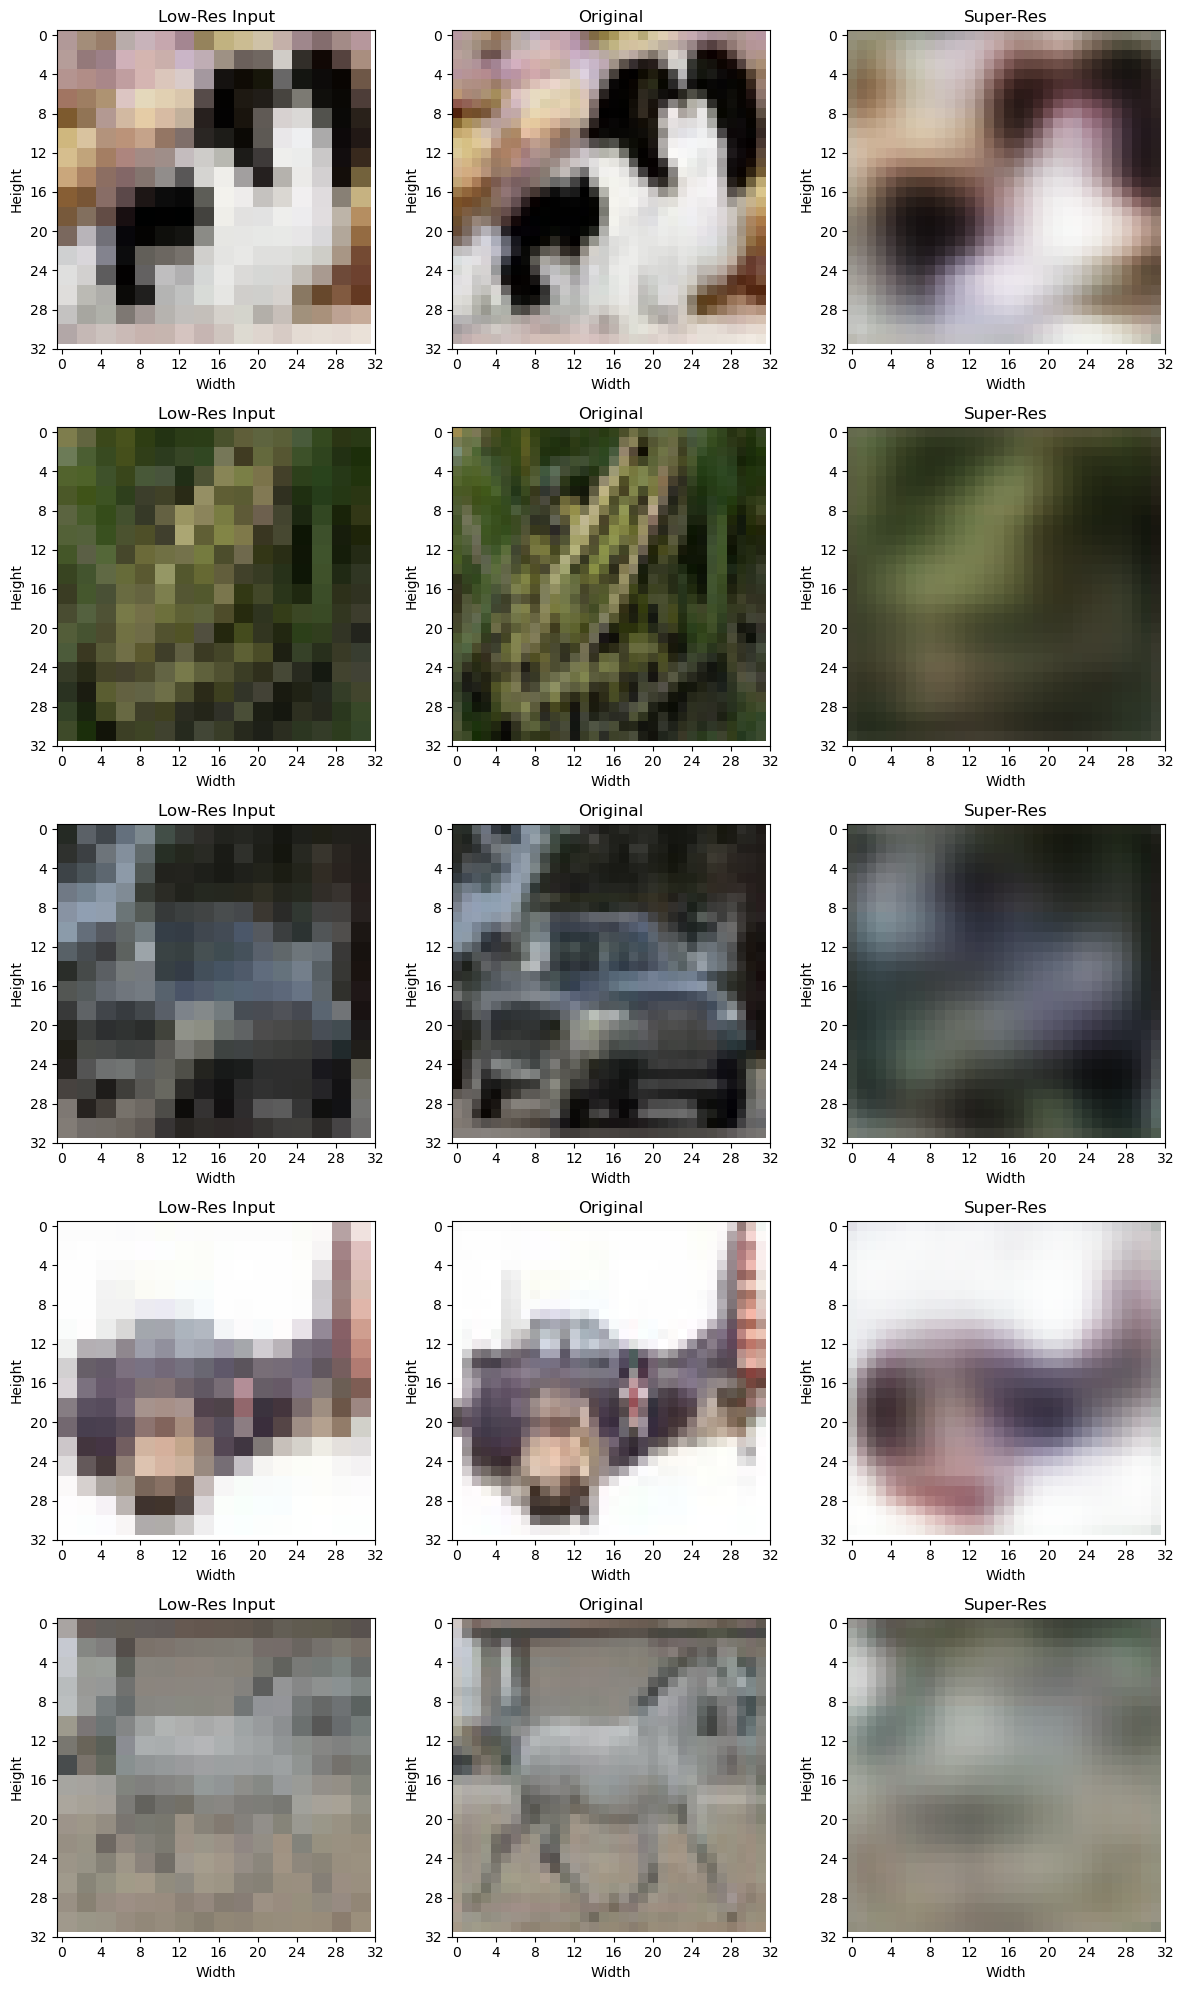

In [79]:
plot_sr_comparison(model2, cifartest_dataset, device, super_res=2, plots=5)


In [56]:
cifartrain(cifardataloaders, model4, loss_fn, optimizer4, epochs, device, super_res=4)

100%|██████████| 30/30 [07:31<00:00, 15.04s/it, train_loss=0.0204, test_loss=0.0203]


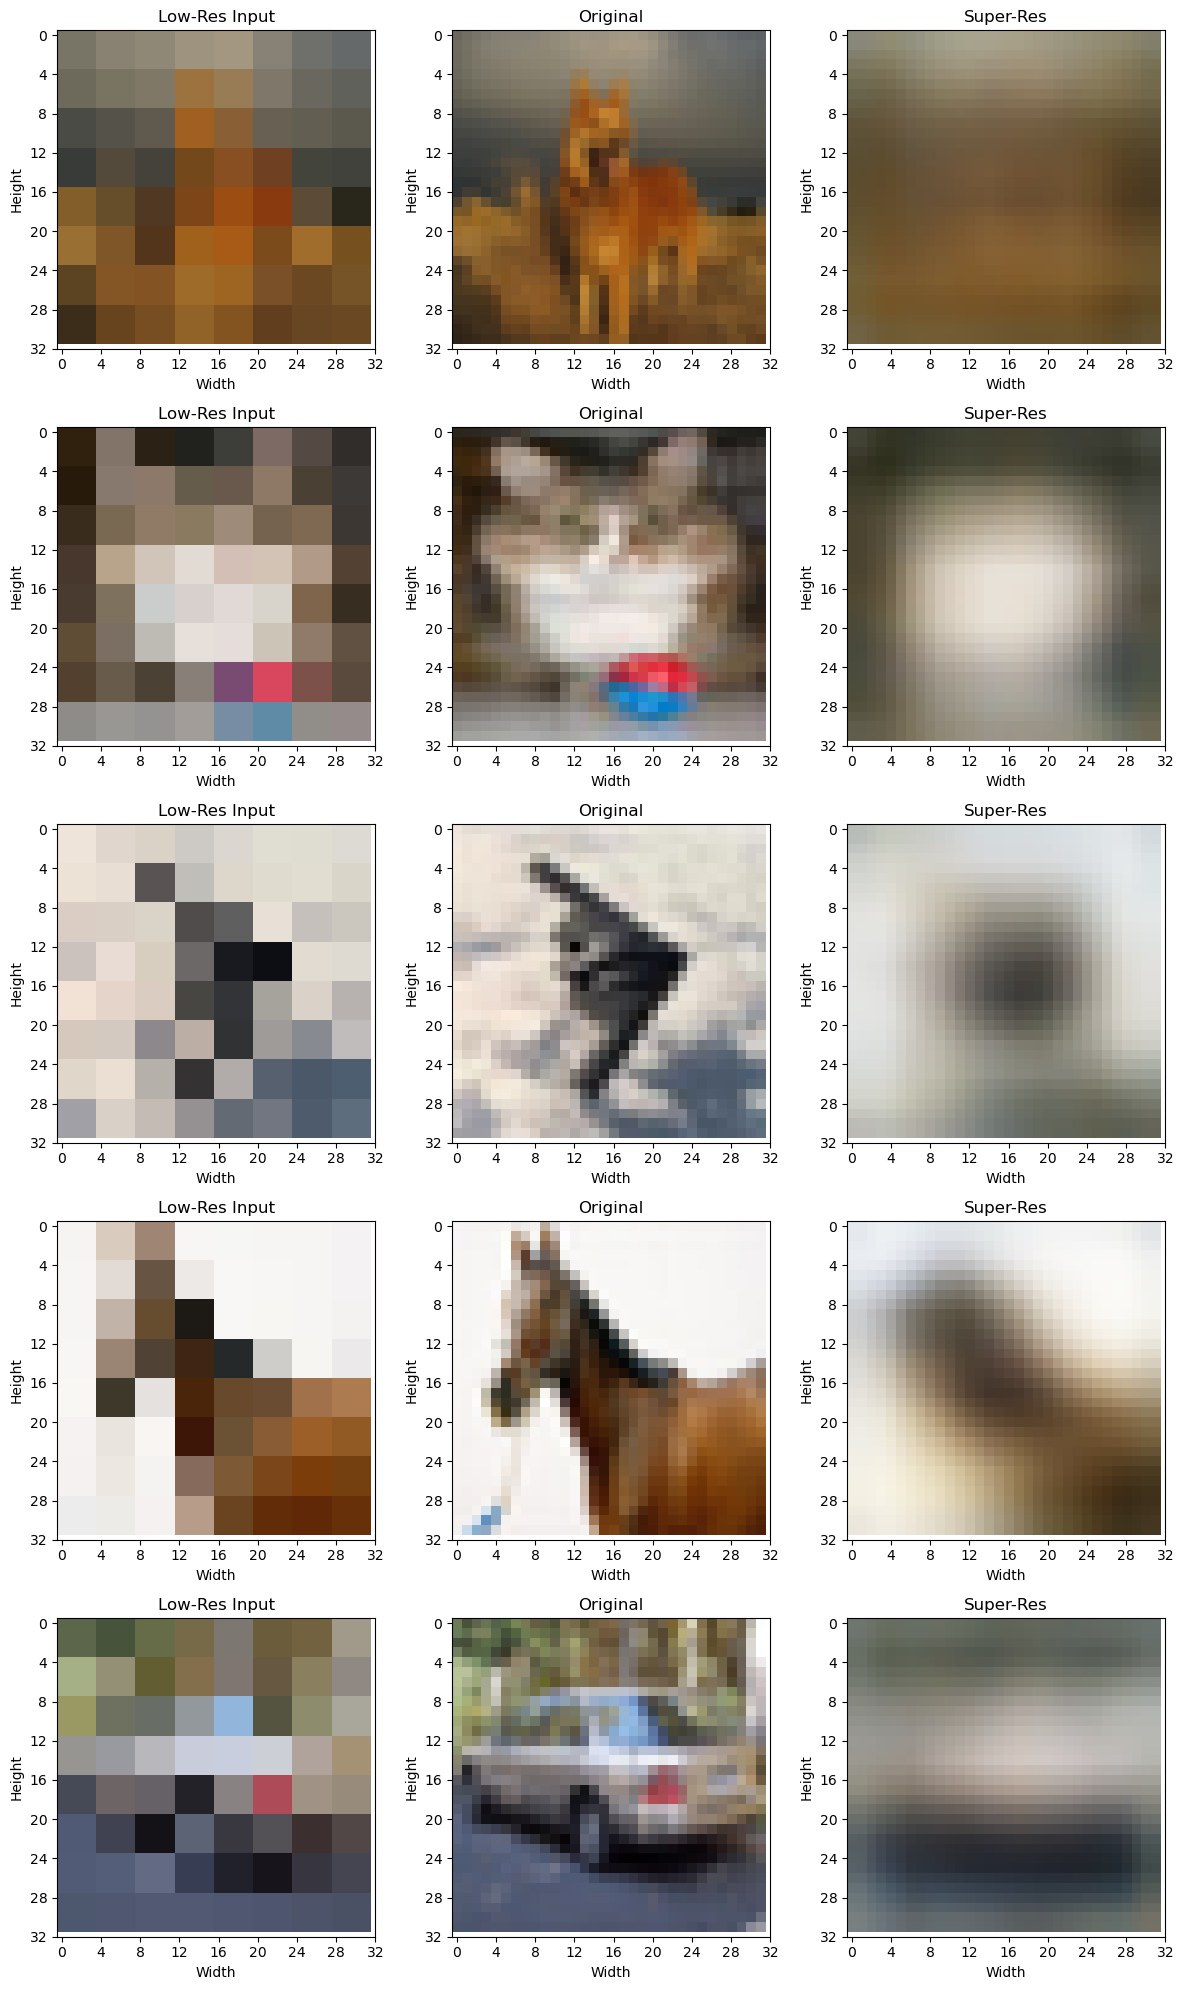

In [70]:
plot_sr_comparison(model4, cifartest_dataset, device, super_res=4, plots=5)

# [Variational Auto-Encoders (VAE)](https://arxiv.org/abs/1906.02691)

Traditional autoencoders reduce the dimension of the input data somehow, figuring out the important features of input images. However, latent vectors often do not make much sense. In other words, taking MNIST dataset as an example, figuring out which digits correspond to different latent vectors is not an easy task, because close latent vectors would not necessarily correspond to the same digits. 

On the other hand, to train *generative* models it is better to have some understanding of the latent space. This idea leads us to **variational auto-encoder** (VAE).

VAE is the autoencoder that learns to predict *statistical distribution* of the latent parameters, so-called **latent distribution**. For example, we can assume that latent vectors would be distributed as $N(\mathrm{z\_mean},e^{\mathrm{z\_log}})$, where $\mathrm{z\_mean}, \mathrm{z\_log} \in\mathbb{R}^d$. Encoder in VAE learns to predict those parameters, and then decoder takes a random vector from this distribution to reconstruct the object.

To summarize:

 * From input vector, we predict `z_mean` and `z_log` (instead of predicting the standard deviation itself, we predict it's logarithm)
 * We sample a vector `sample(z_val in code)` from the distribution $N(\mathrm{z\_mean},e^{\mathrm{z\_log\_sigma}})$
 * Decoder tries to decode the original image using `sample` as an input vector

 <img src="images/vae.png" width="50%">

 > Image from [this blog post](https://ijdykeman.github.io/ml/2016/12/21/cvae.html) by Isaak Dykeman

In [12]:
class VAEEncoder(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.intermediate_dim = 512
        self.latent_dim = 2
        self.linear = nn.Linear(784, self.intermediate_dim)
        self.z_mean = nn.Linear(self.intermediate_dim, self.latent_dim)
        self.z_log = nn.Linear(self.intermediate_dim, self.latent_dim)
        self.relu = nn.ReLU()
        self.device = device

    def forward(self, input):
        bs = input.shape[0]

        hidden = self.relu(self.linear(input))
        z_mean = self.z_mean(hidden)
        z_log = self.z_log(hidden)

        eps = torch.FloatTensor(np.random.normal(size=(bs, self.latent_dim))).to(device)
        z_val = z_mean + torch.exp(z_log) * eps
        return z_mean, z_log, z_val

In [13]:
class VAEDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.intermediate_dim = 512
        self.latent_dim = 2
        self.linear = nn.Linear(self.latent_dim, self.intermediate_dim)
        self.output = nn.Linear(self.intermediate_dim, 784)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, input):
        hidden = self.relu(self.linear(input))
        decoded = self.sigmoid(self.output(hidden))
        return decoded

In [14]:
class VAEAutoEncoder(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.encoder = VAEEncoder(device)
        self.decoder = VAEDecoder()
        self.z_vals = None

    def forward(self, input):
        bs, c, h, w = input.shape[0], input.shape[1], input.shape[2], input.shape[3]
        input = input.view(bs, -1)
        encoded = self.encoder(input)
        self.z_vals = encoded
        decoded = self.decoder(encoded[2])
        return decoded
    
    def get_zvals(self):
        return self.z_vals

Variational auto-encoders use complex loss function that consists of two parts:
* **Reconstruction loss** is the loss function that shows how close reconstructed image is to the target (can be MSE). It is the same loss function as in normal autoencoders.
* **KL loss**, which ensures that latent variable distributions stays close to normal distribution. It is based on the notion of [Kullback-Leibler divergence](https://www.countbayesie.com/blog/2017/5/9/kullback-leibler-divergence-explained) - a metric to estimate how similar two statistical distributions are.

In [15]:
def vae_loss(preds, targets, z_vals):
    mse = nn.MSELoss()
    reconstruction_loss = mse(preds, targets.view(targets.shape[0], -1)) * 784.0
    temp = 1.0 + z_vals[1] - torch.square(z_vals[0]) - torch.exp(z_vals[1])
    kl_loss = -0.5 * torch.sum(temp, axis=-1)
    return torch.mean(reconstruction_loss + kl_loss)

In [21]:
model = VAEAutoEncoder(device).to(device)
optimizer = optim.RMSprop(model.parameters(), lr=lr, eps=eps)

In [17]:
def train_vae(dataloaders, model, optimizer, epochs, device):
    tqdm_iter = tqdm(range(epochs))
    train_dataloader, test_dataloader = dataloaders[0], dataloaders[1]

    for epoch in tqdm_iter:
        model.train()
        train_loss = 0.0
        test_loss = 0.0

        for batch in train_dataloader:
            imgs, labels = batch
            imgs = imgs.to(device)
            labels = labels.to(device)

            preds = model(imgs)
            z_vals = model.get_zvals()
            loss = vae_loss(preds, imgs, z_vals)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            for batch in test_dataloader:
                imgs, labels = batch
                imgs = imgs.to(device)
                labels = labels.to(device)

                preds = model(imgs)
                z_vals = model.get_zvals()
                loss = vae_loss(preds, imgs, z_vals)

                test_loss += loss.item()

        train_loss /= len(train_dataloader)
        test_loss /= len(test_dataloader)

        tqdm_dct = {'train loss:': train_loss, 'test loss:': test_loss}
        tqdm_iter.set_postfix(tqdm_dct, refresh=True)
        tqdm_iter.refresh()

In [ ]:
train_vae(dataloaders, model, optimizer, epochs, device)

100%|██████████| 30/30 [06:28<00:00, 12.96s/it, train loss:=33.8, test loss:=34.9]


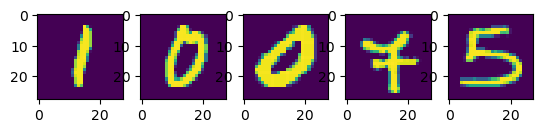

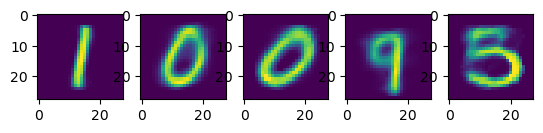

In [25]:
model.eval()
predictions = []
plots = 5
for i, data in enumerate(test_dataset):
    if i == plots:
        break
    predictions.append(model(data[0].to(device).unsqueeze(0)).view(1, 28, 28).detach().cpu())
plotn(plots, test_dataset)
plotn(plots, predictions)

> **Task**: In our sample, we have trained fully-connected VAE. Now take the CNN from traditional auto-encoder above and create CNN-based VAE.

In [ ]:
# class CNNVAEEncoder(nn.Module):
#     def __init__(self, latent_dim=16):
#         super().__init__()
#         self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
#         self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
#         self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
#         self.pool = nn.MaxPool2d(2, 2)
#         self.relu = nn.ReLU()

#         self.flatten = nn.Flatten()
#         self.fc_mu = nn.Linear(64*4*4, latent_dim)
#         self.fc_logvar = nn.Linear(64*4*4, latent_dim)

#     def forward(self, x):
#         x = self.pool(self.relu(self.conv1(x)))
#         x = self.pool(self.relu(self.conv2(x)))
#         x = self.pool(self.relu(self.conv3(x)))

#         x = self.flatten(x)

#         mu = self.fc_mu(x)
#         logvar = self.fc_logvar(x)

#         return mu, logvar

In [42]:
class CNNVAEEncoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()

        # dummy pass to compute the flattened dimension
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 28, 28)  # MNIST size
            out = self.pool(self.relu(self.conv1(dummy)))
            out = self.pool(self.relu(self.conv2(out)))
            out = self.pool(self.relu(self.conv3(out)))
            flat_dim = out.numel()

        self.fc_mu = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.flatten(x)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

In [35]:
class CNNVAEDecoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64*4*4)

        self.upsample = nn.Upsample(scale_factor=2)
        self.conv1 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(16, 1, kernel_size=3, padding=1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 64, 4, 4)

        x = self.upsample(self.relu(self.conv1(x)))
        x = self.upsample(self.relu(self.conv2(x)))
        x = self.upsample(self.relu(self.conv3(x)))

        return x[:, :, :28, :28]

In [36]:
class CNNVAEAutoEncoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = CNNVAEEncoder(latent_dim)
        self.decoder = CNNVAEDecoder(latent_dim)
        self.z_vals = None  # store (mu, logvar, z) for loss function

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        recon = self.decoder(z)

        self.z_vals = (mu, logvar, z)  # so train_vae can fetch them
        return recon

    def get_zvals(self):
        return self.z_vals

In [37]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [38]:
def vae_loss(preds, targets, z_vals):
    mse = nn.MSELoss()
    reconstruction_loss = mse(preds, targets) * 784.0  # still fine for MNIST
    mu, logvar, _ = z_vals
    temp = 1.0 + logvar - torch.square(mu) - torch.exp(logvar)
    kl_loss = -0.5 * torch.sum(temp, axis=-1)
    return torch.mean(reconstruction_loss + kl_loss)


In [43]:
model = CNNVAEAutoEncoder(2).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, eps=eps)

In [44]:
train_vae(dataloaders, model, optimizer, epochs, device)

100%|██████████| 30/30 [08:37<00:00, 17.23s/it, train loss:=40.9, test loss:=41]  


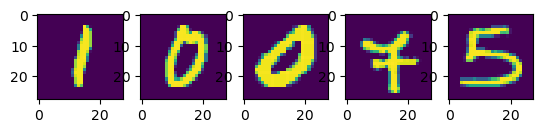

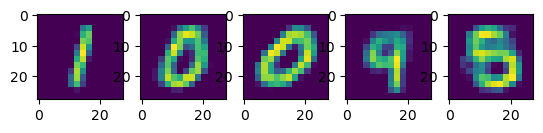

In [45]:
model.eval()
predictions = []
plots = 5
for i, data in enumerate(test_dataset):
    if i == plots:
        break
    img = data[0].to(device).unsqueeze(0)        # (1,1,28,28)
    recon = model(img).detach().cpu()            # (1,1,28,28)
    predictions.append(recon.squeeze(0))         # (1,28,28) to match plotn

plotn(plots, test_dataset)       # original test images
plotn(plots, predictions)        # reconstructed images


# [Adversarial Auto-Encoders (AAE)](https://arxiv.org/abs/1511.05644)

Adversarial Auto-Encoders is a **combination** of Generative Adversarial Networks and Variational Auto-Encoders. 

Encoder will be the generator, discriminator will learn to distinguish the real images encoder output from generated ones. Encoder output is a distribution, from this output decoder will try decode image.

In this approach we have **three loss functions**: generator loss, discriminator loss from GAN's and reconstruction loss from VAE.

 <img src="images/aae.png" width="50%">

 > Image from [this blog post](https://blog.paperspace.com/adversarial-autoencoders-with-pytorch/) by Felipe Ducau

In [46]:
class AAEEncoder(nn.Module):
    def __init__(self, input_dim, inter_dim, latent_dim):
        super().__init__()
        self.linear1 = nn.Linear(input_dim, inter_dim)
        self.linear2 = nn.Linear(inter_dim, inter_dim)
        self.linear3 = nn.Linear(inter_dim, inter_dim)
        self.linear4 = nn.Linear(inter_dim, latent_dim)
        self.relu = nn.ReLU()
        
    def forward(self, input):
        hidden1 = self.relu(self.linear1(input))
        hidden2 = self.relu(self.linear2(hidden1))
        hidden3 = self.relu(self.linear3(hidden2))
        encoded = self.linear4(hidden3)
        return encoded

In [47]:
class AAEDecoder(nn.Module):
    def __init__(self, latent_dim, inter_dim, output_dim):
        super().__init__()
        self.linear1 = nn.Linear(latent_dim, inter_dim)
        self.linear2 = nn.Linear(inter_dim, inter_dim)
        self.linear3 = nn.Linear(inter_dim, inter_dim)
        self.linear4 = nn.Linear(inter_dim, output_dim)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, input):
        hidden1 = self.relu(self.linear1(input))
        hidden2 = self.relu(self.linear2(hidden1))
        hidden3 = self.relu(self.linear3(hidden2))
        decoded = self.sigmoid(self.linear4(hidden3))
        return decoded

In [48]:
class AAEDiscriminator(nn.Module):
    def __init__(self, latent_dim, inter_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.inter_dim = inter_dim
        self.linear1 = nn.Linear(latent_dim, inter_dim)
        self.linear2 = nn.Linear(inter_dim, inter_dim)
        self.linear3 = nn.Linear(inter_dim, inter_dim)
        self.linear4 = nn.Linear(inter_dim, inter_dim)
        self.linear5 = nn.Linear(inter_dim, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, input):
        hidden1 = self.relu(self.linear1(input))
        hidden2 = self.relu(self.linear2(hidden1))
        hidden3 = self.relu(self.linear3(hidden2))
        hidden4 = self.relu(self.linear4(hidden3))
        decoded = self.sigmoid(self.linear4(hidden4))
        return decoded
    
    def get_dims(self):
        return self.latent_dim, self.inter_dim
        

In [49]:
input_dims = 784
inter_dims = 1000
latent_dims = 150

In [50]:
aae_encoder = AAEEncoder(input_dims, inter_dims, latent_dims).to(device)
aae_decoder = AAEDecoder(latent_dims, inter_dims, input_dims).to(device)
aae_discriminator = AAEDiscriminator(latent_dims, int(inter_dims / 2)).to(device)

In [51]:
lr = 1e-4
regularization_lr = 5e-5

In [52]:
optim_encoder = optim.Adam(aae_encoder.parameters(), lr=lr)
optim_encoder_regularization = optim.Adam(aae_encoder.parameters(), lr=regularization_lr)
optim_decoder = optim.Adam(aae_decoder.parameters(), lr=lr)
optim_discriminator = optim.Adam(aae_discriminator.parameters(), lr=regularization_lr)

In [53]:
def train_aae(dataloaders, models, optimizers, epochs, device):
    tqdm_iter = tqdm(range(epochs))
    train_dataloader, test_dataloader = dataloaders[0], dataloaders[1]
    
    enc, dec, disc = models[0], models[1], models[2]
    optim_enc, optim_enc_reg, optim_dec, optim_disc = optimizers[0], optimizers[1], optimizers[2], optimizers[3]
    
    eps = 1e-9

    for epoch in tqdm_iter:
        enc.train()
        dec.train()
        disc.train()

        train_reconst_loss = 0.0
        train_disc_loss = 0.0
        train_enc_loss = 0.0
        
        test_reconst_loss = 0.0
        test_disc_loss = 0.0
        test_enc_loss = 0.0

        for batch in train_dataloader:
            imgs, labels = batch
            imgs = imgs.view(imgs.shape[0], -1).to(device)
            labels = labels.to(device)
            
            enc.zero_grad()
            dec.zero_grad()
            disc.zero_grad()
             
            encoded = enc(imgs)
            decoded = dec(encoded)
            
            reconstruction_loss = F.binary_cross_entropy(decoded, imgs)
            reconstruction_loss.backward()
            
            optim_enc.step()
            optim_dec.step()
            enc.eval()

            latent_dim, disc_inter_dim = disc.get_dims()
            real = torch.randn(imgs.shape[0], latent_dim).to(device)
            
            disc_real = disc(real)
            disc_fake = disc(enc(imgs))
            
            disc_loss = -torch.mean(torch.log(disc_real + eps) + torch.log(1.0 - disc_fake + eps))
            disc_loss.backward()
            
            optim_dec.step()
            enc.train()
            
            disc_fake = disc(enc(imgs))
            enc_loss = -torch.mean(torch.log(disc_fake + eps))
            enc_loss.backward()
            
            optim_enc_reg.step()

            train_reconst_loss += reconstruction_loss.item()
            train_disc_loss += disc_loss.item()
            train_enc_loss += enc_loss.item()

        enc.eval()
        dec.eval()
        disc.eval()

        with torch.no_grad():
            for batch in test_dataloader:
                imgs, labels = batch
                imgs = imgs.view(imgs.shape[0], -1).to(device)
                labels = labels.to(device)

                encoded = enc(imgs)
                decoded = dec(encoded)

                reconstruction_loss = F.binary_cross_entropy(decoded, imgs)

                latent_dim, disc_inter_dim = disc.get_dims()
                real = torch.randn(imgs.shape[0], latent_dim).to(device)

                disc_real = disc(real)
                disc_fake = disc(enc(imgs))
                disc_loss = -torch.mean(torch.log(disc_real + eps) + torch.log(1.0 - disc_fake + eps))

                disc_fake = disc(enc(imgs))
                enc_loss = -torch.mean(torch.log(disc_fake + eps))

                test_reconst_loss += reconstruction_loss.item()
                test_disc_loss += disc_loss.item()
                test_enc_loss += enc_loss.item()

        train_reconst_loss /= len(train_dataloader)
        train_disc_loss /= len(train_dataloader)
        train_enc_loss /= len(train_dataloader)
        
        test_reconst_loss /= len(test_dataloader)
        test_disc_loss /= len(test_dataloader)
        test_enc_loss /= len(test_dataloader)

        tqdm_dct = {'train reconst loss:': train_reconst_loss, 'train disc loss:': train_disc_loss, 'train enc loss': train_enc_loss, \
                        'test reconst loss:': test_reconst_loss, 'test disc loss:': test_disc_loss, 'test enc loss': test_enc_loss}
        tqdm_iter.set_postfix(tqdm_dct, refresh=True)
        tqdm_iter.refresh()

In [54]:
models = (aae_encoder, aae_decoder, aae_discriminator)
optimizers = (optim_encoder, optim_encoder_regularization, optim_decoder, optim_discriminator)

In [55]:
train_aae(dataloaders, models, optimizers, epochs, device)

100%|██████████| 30/30 [12:34<00:00, 25.14s/it, train reconst loss:=0.0909, train disc loss:=1.39, train enc loss=0.694, test reconst loss:=0.093, test disc loss:=1.39, test enc loss=0.694] 


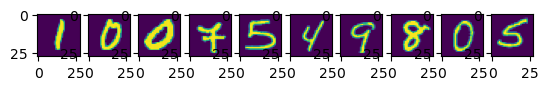

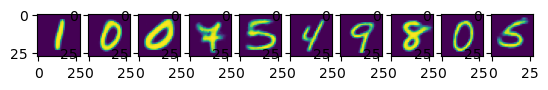

In [56]:
aae_encoder.eval()
aae_decoder.eval()
predictions = []
plots = 10
for i, data in enumerate(test_dataset):
    if i == plots:
        break
    pred = aae_decoder(aae_encoder(data[0].to(device).unsqueeze(0).view(1, 784)))
    predictions.append(pred.view(1, 28, 28).detach().cpu())
plotn(plots, test_dataset)
plotn(plots, predictions)

## Additional Materials

* [Blog post on NeuroHive](https://neurohive.io/ru/osnovy-data-science/variacionnyj-avtojenkoder-vae/)
* [Variational Autoencoders Explained](https://kvfrans.com/variational-autoencoders-explained/)